# DoubleIntegrator - Stage 4d - Barrier-Adaptation Collapse Sweep

Sweep adaptation settings and identify failure regimes.


## 1. Setup and fixed scenario

Create the matched test scenario.


In [ ]:
import copy
import sys
import time
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

_p = Path.cwd()
while not (_p / "src" / "sdpc").exists():
    _p = _p.parent
sys.path.insert(0, str(_p / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from sdpc.adaptation import SafeAdaptationConfig, run_safe_adaptation
from sdpc.config import load_config
from sdpc.eval import (
    CollapseCriteria,
    compute_metrics,
    diagnose_tracking_collapse,
    sample_scenario,
)
from sdpc.plotting import plot_trajectories_with_ellipse
from sdpc.registry import make_system
from sdpc.sindy import load_model

SYSTEM = "double_integrator"
device = torch.device("cpu")
system = make_system(SYSTEM, device=device)
CONFIGS = Path.cwd().parent / "configs"
RESULTS = Path.cwd().parent / "results"

cfg = load_config(CONFIGS / "safe.yaml")
from sdpc.io import find_policy_checkpoint
policy_path = find_policy_checkpoint(RESULTS, cfg)
base_policy = load_model(policy_path, device=device)

# Use the complete configured experiment so delayed convergence is not
# misclassified as failure. Reduce this only for exploratory debugging.
N_STEPS = int(cfg.get("nsteps", 300))
scenario_cfg = copy.deepcopy(cfg)
scenario_cfg["nsteps"] = N_STEPS
data = sample_scenario(system, scenario_cfg, cfg.get("seed", 0), device)

plant = system.perturbed_plant(cfg)
derivative_model = system.perturbed_sindy_model(cfg)

print("Initial state :", data["xn"][0, 0].tolist())
print("Reference     :", data["r"][0, -1].tolist())
print("Sweep steps  :", N_STEPS)


## 2. Collapse and reference-reaching criteria

Analyze sensitivity to configuration.


In [2]:
REACH_TOLERANCE = 0.10
REACH_HOLD_STEPS = 10

criteria = CollapseCriteria(
    reach_tolerance=REACH_TOLERANCE,
    reach_hold_steps=REACH_HOLD_STEPS,
    analysis_start_fraction=0.25,
    motion_deadband=1.0e-3,
    min_direction_reversals=6,
    min_backtrack_ratio=0.15,
)
criteria


CollapseCriteria(reach_tolerance=0.1, reach_hold_steps=10, analysis_start_fraction=0.25, motion_deadband=0.001, min_direction_reversals=6, min_backtrack_ratio=0.15)

## 3. Reproducible experiment runner

Define the repeatable experiment.


In [3]:
DERIVATIVE_BACKEND = "symbolic"  # switch to "autograd" for confirmation
MAX_SAFETY_ITERS = 50

base_safe = dict(cfg.get("safe", {}))
base_safe.update({
    "ref_backend": DERIVATIVE_BACKEND,
    "safety_backend": DERIVATIVE_BACKEND,
    "max_safety_iters": MAX_SAFETY_ITERS,
})

stored_runs = {}


def _status(row):
    if row.get("invalid_config", False):
        return "invalid"
    if row.get("error"):
        return "error"
    if row.get("collapsed", False):
        return "collapse"
    if row.get("safety_failure", False):
        return "safety_failure"
    if row.get("not_reached", False):
        return "not_reached"
    if row.get("back_and_forth", False):
        return "oscillatory_reached"
    return "stable"


def run_case(label, *, safe_overrides=None, obstacle_band=None, du_max=None, store=True):
    case_cfg = copy.deepcopy(cfg)
    case_cfg["nsteps"] = N_STEPS
    case_cfg["safe"] = dict(base_safe)
    case_cfg["safe"].update(safe_overrides or {})
    case_cfg["safe"]["max_safety_iters"] = MAX_SAFETY_ITERS
    if obstacle_band is not None:
        case_cfg.setdefault("bands", {})["obstacle"] = float(obstacle_band)
    if du_max is not None:
        case_cfg["du_max"] = float(du_max)

    band_du = float(case_cfg.get("bands", {}).get("du", 0.0))
    configured_du_max = case_cfg.get("du_max")
    if configured_du_max is not None and band_du >= float(configured_du_max) ** 2:
        return {
            "label": label,
            "invalid_config": True,
            "error": f"bands.du={band_du} must be smaller than du_max**2={float(configured_du_max) ** 2}",
            "status": "invalid",
        }

    safe_cfg = SafeAdaptationConfig(**case_cfg["safe"])
    assert safe_cfg.max_safety_iters == 50
    spec = system.safety_specs(case_cfg)
    policy = copy.deepcopy(base_policy)

    started = time.perf_counter()
    try:
        result = run_safe_adaptation(
            policy,
            plant,
            data,
            spec,
            safe_cfg,
            umin=system.umin,
            umax=system.umax,
            pred_plant=plant,
            derivative_model=derivative_model,
            system=system,
        )
    except Exception as exc:
        return {
            "label": label,
            "invalid_config": False,
            "error": f"{type(exc).__name__}: {exc}",
            "status": "error",
        }

    elapsed = time.perf_counter() - started
    diagnostic = diagnose_tracking_collapse(result["x_traj"], data["r"], criteria)
    metrics = compute_metrics(
        result["x_traj"], result["u_traj"], data["r"],
        spec=spec, logs=result["logs"],
    )
    logs = result["logs"]
    cap_hits = sum(
        row["safety_iters"] >= MAX_SAFETY_ITERS and not row["predicted_safe"]
        for row in logs
    )
    row = {
        "label": label,
        "invalid_config": False,
        "error": "",
        **diagnostic,
        "tracking_mse": metrics["tracking_mse"],
        "state_violations": metrics["num_state_violations"],
        "du_violations": metrics.get("num_control_rate_violations", 0),
        "min_state_margin": metrics["min_state_margin"],
        "min_du_margin": metrics.get("min_control_rate_margin", np.nan),
        "smooth_rms_du": metrics["control_smoothness_rms"],
        "max_du_l2": metrics["max_du_l2"],
        "predicted_safe_fraction": sum(row_["predicted_safe"] for row_ in logs) / len(logs),
        "guard_cap_fraction": cap_hits / len(logs),
        "total_safety_iters": sum(row_["safety_iters"] for row_ in logs),
        "wall_time_s": elapsed,
    }
    row["safety_failure"] = bool(
        row["predicted_safe_fraction"] < 1.0
        or row["state_violations"] > 0
        or row["du_violations"] > 0
    )
    row["status"] = _status(row)
    if store:
        stored_runs[label] = {"result": result, "summary": row, "cfg": case_cfg, "spec": spec}
    return row


## 4. Baseline sanity check

Check the expected behavior.


In [4]:
baseline_row = run_case("baseline")
display(pd.DataFrame([baseline_row]).set_index("label"))

if baseline_row["status"] != "stable":
    print("The baseline itself is not stable under the selected collapse criteria.")


,invalid_config,error,reached_reference,time_to_reach,not_reached,back_and_forth,collapsed,final_tracking_error,minimum_tracking_error,tail_mean_tracking_error,...,min_state_margin,min_du_margin,smooth_rms_du,max_du_l2,predicted_safe_fraction,guard_cap_fraction,total_safety_iters,wall_time_s,safety_failure,status
label,,,,,,,,,,,,,,,,,,,,,
baseline,False,,True,184.0,False,False,False,0.000279,0.000009,0.000469,...,0.871928,0.988649,0.016333,0.10654,1.0,0.0,69,1.163378,False,stable


## 5. One-factor-at-a-time sweep

Analyze sensitivity to configuration.


In [5]:
SWEEP_VALUES = {
    "gamma_ref": [1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2, 1e-1, 2e-1, 5e-1],
    "gamma_safe": [1e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2, 1e-1],
    "horizon": [3, 5, 10, 20, 30, 40],
    "clip_update": [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0],
    "safety_grad_max_norm": [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 20.0],
    "obstacle_band": [0.0, 0.5, 1.0, 2.0, 4.0],
    "du_max": [0.12, 0.2, 0.3, 0.5, 1.0],
}


def baseline_value(parameter):
    if parameter == "obstacle_band":
        return float(cfg.get("bands", {}).get("obstacle", 0.0))
    if parameter == "du_max":
        return float(cfg["du_max"])
    return base_safe[parameter]


factor_rows = []
for parameter, values in SWEEP_VALUES.items():
    base_value = baseline_value(parameter)
    for value in values:
        label = f"{parameter}={value:g}"
        print(f"running {label}")
        if parameter != "gamma_ref" and float(value) == float(base_value):
            row = dict(baseline_row)
            row["label"] = label
        elif parameter == "obstacle_band":
            row = run_case(label, obstacle_band=value)
        elif parameter == "du_max":
            row = run_case(label, du_max=value)
        elif parameter == "gamma_ref":
            row = run_case(label, safe_overrides={"gamma_ref": value, "adaptive_gamma": False})
        else:
            row = run_case(label, safe_overrides={parameter: value})
        row["parameter"] = parameter
        row["value"] = value
        factor_rows.append(row)

factor_df = pd.DataFrame(factor_rows)
factor_df["status"] = factor_df.apply(lambda row: _status(row), axis=1)
print()
print("Outcome counts:")
display(factor_df.groupby(["parameter", "status"]).size().unstack(fill_value=0))


running gamma_ref=0.0001
running gamma_ref=0.0005
running gamma_ref=0.001
running gamma_ref=0.005
running gamma_ref=0.01
running gamma_ref=0.05
running gamma_ref=0.1
running gamma_ref=0.2
running gamma_ref=0.5
running gamma_safe=1e-05
running gamma_safe=0.0001
running gamma_safe=0.0005
running gamma_safe=0.001
running gamma_safe=0.005
running gamma_safe=0.01
running gamma_safe=0.05
running gamma_safe=0.1
running horizon=3
running horizon=5
running horizon=10
running horizon=20
running horizon=30
running horizon=40
running clip_update=0.01
running clip_update=0.05
running clip_update=0.1
running clip_update=0.5
running clip_update=1
running clip_update=2
running clip_update=5
running clip_update=10
running safety_grad_max_norm=0.01
running safety_grad_max_norm=0.05
running safety_grad_max_norm=0.1
running safety_grad_max_norm=0.5
running safety_grad_max_norm=1
running safety_grad_max_norm=5
running safety_grad_max_norm=10
running safety_grad_max_norm=20
running obstacle_band=0
running o

status,collapse,not_reached,safety_failure,stable
parameter,,,,
clip_update,0,3,0,5
du_max,0,0,0,5
gamma_ref,3,3,3,0
gamma_safe,2,0,2,4
horizon,0,0,0,6
obstacle_band,0,0,1,4
safety_grad_max_norm,0,0,1,7


## 6. Collapse candidates and parameter trends

Build the candidate sparse model.


,parameter,value,status,reached_reference,back_and_forth,final_tracking_error,tail_mean_tracking_error,direction_reversals,backtrack_ratio,predicted_safe_fraction,guard_cap_fraction,state_violations,du_violations,smooth_rms_du,wall_time_s
0,gamma_safe,0.10000,collapse,False,True,6.101387,6.124781,13,1.405186e+00,1.000000,0.000000,0,0,0.071716,0.634999
1,gamma_ref,0.00010,collapse,False,True,6.116920,6.119328,7,8.770904e-01,1.000000,0.000000,0,0,0.006982,0.717623
2,gamma_ref,0.00050,collapse,False,True,6.030238,6.023767,48,9.195294e-01,1.000000,0.000000,0,0,0.011074,0.705961
3,gamma_ref,0.00100,collapse,False,True,5.982285,5.980628,95,7.465965e-01,1.000000,0.000000,0,0,0.013604,0.760982
4,gamma_safe,0.05000,collapse,False,True,5.713151,5.819495,19,8.862580e-01,1.000000,0.000000,0,0,0.079669,0.700205
5,clip_update,0.01000,not_reached,False,False,5.969290,5.970352,0,8.077840e+09,1.000000,0.000000,0,0,0.004518,2.460334
6,clip_update,0.05000,not_reached,False,False,5.941413,5.943222,1,6.424939e+00,1.000000,0.000000,0,0,0.006473,2.203790
7,gamma_ref,0.05000,not_reached,False,False,0.559267,0.757409,3,5.132434e-01,1.000000,0.000000,0,0,0.044190,1.057105
8,gamma_ref,0.00500,not_reached,False,False,0.281928,0.734734,0,0.000000e+00,1.000000,0.000000,0,0,0.014071,0.897964
9,clip_update,0.10000,not_reached,False,False,0.295842,0.403705,0,0.000000e+00,1.000000,0.000000,0,0,0.009559,1.373226


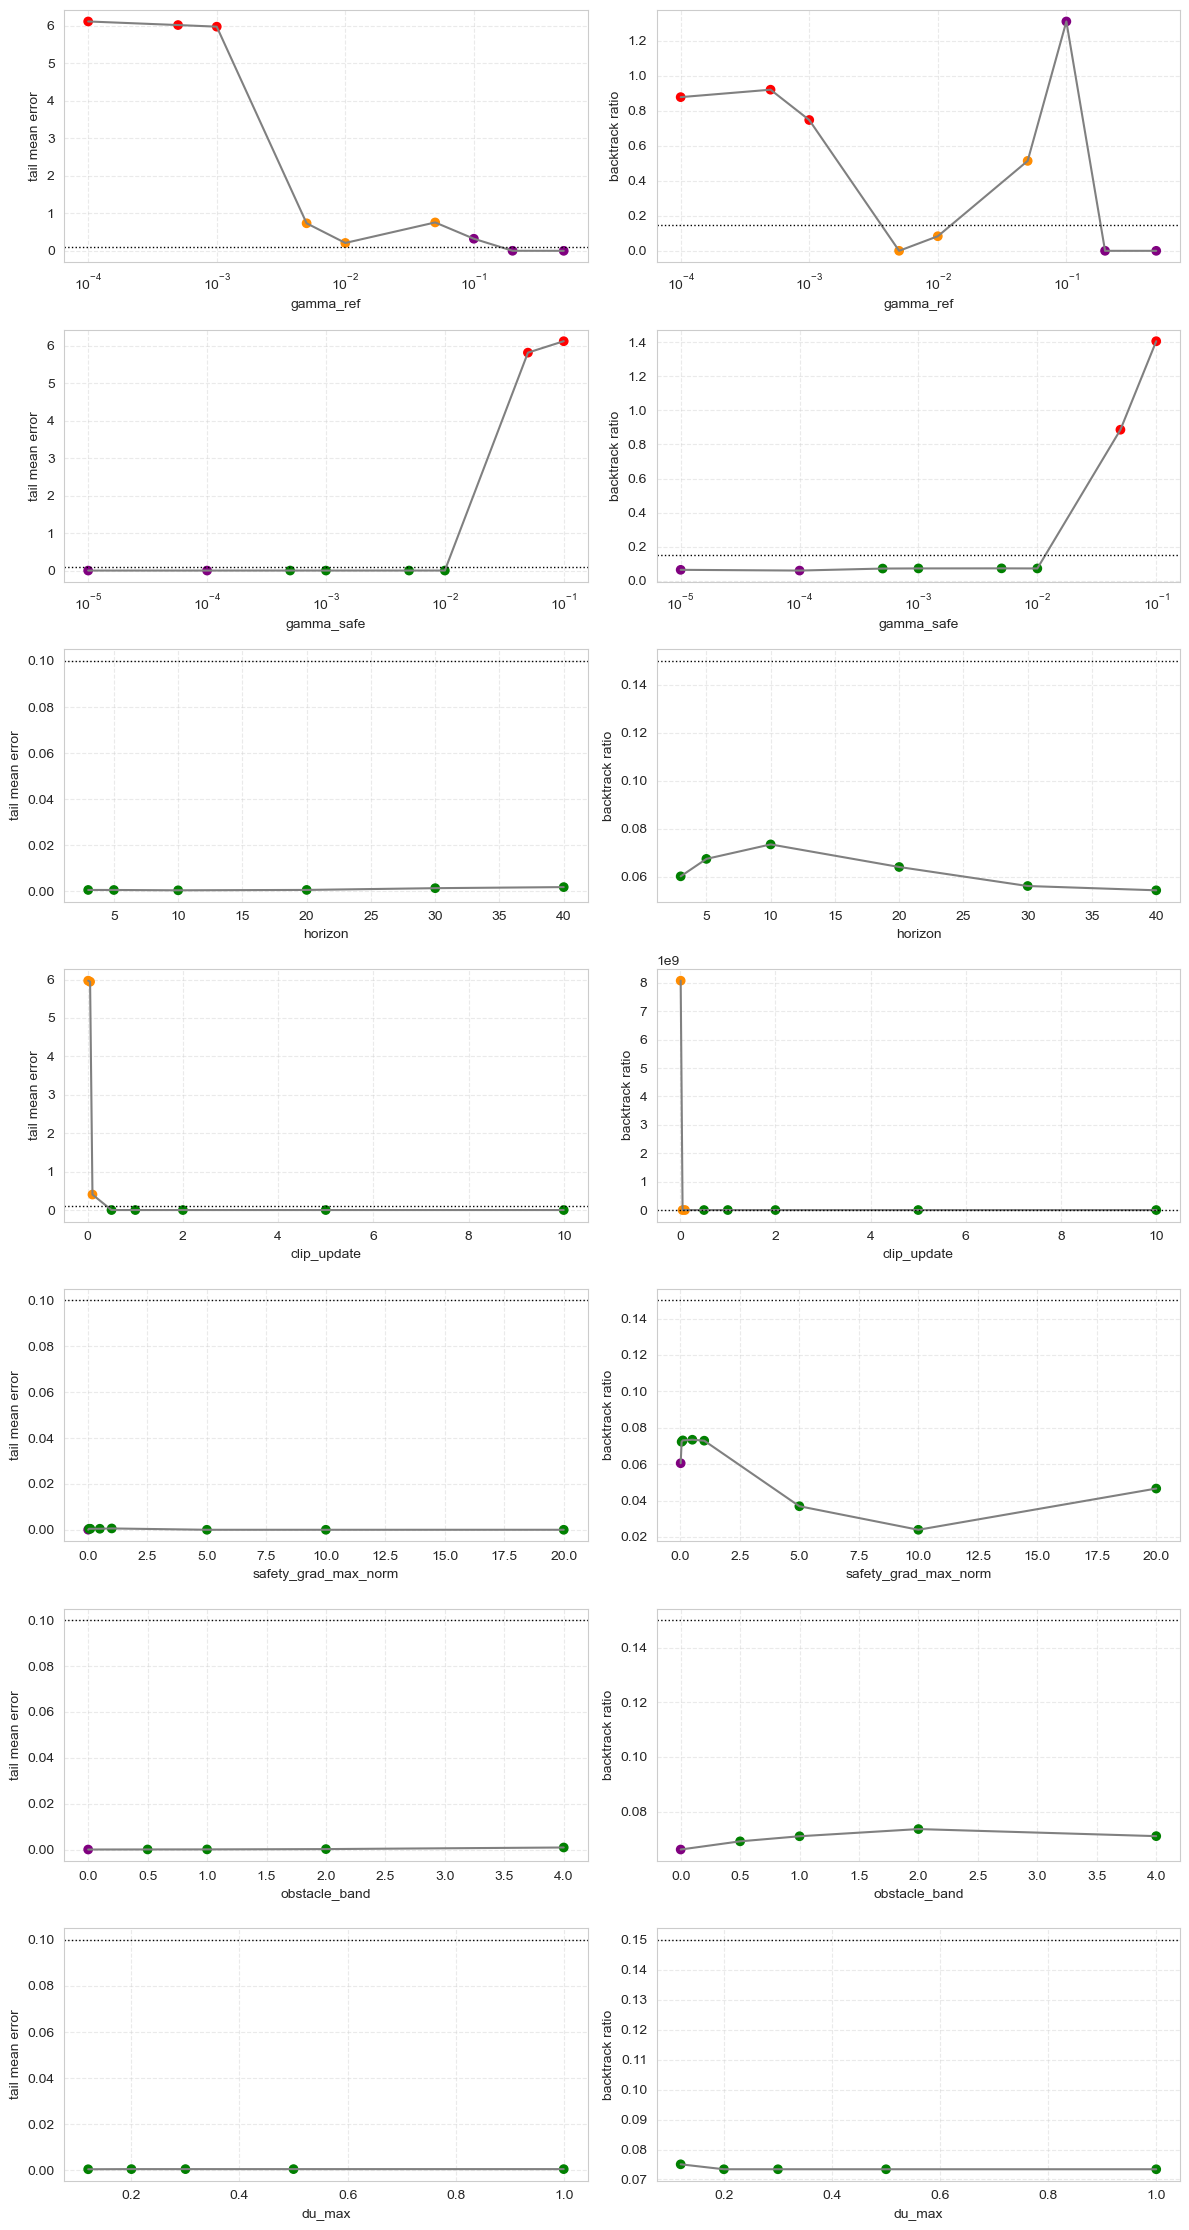

In [6]:
report_columns = [
    "parameter", "value", "status", "reached_reference", "back_and_forth",
    "final_tracking_error", "tail_mean_tracking_error", "direction_reversals",
    "backtrack_ratio", "predicted_safe_fraction", "guard_cap_fraction",
    "state_violations", "du_violations", "smooth_rms_du", "wall_time_s",
]

collapse_candidates = factor_df[
    factor_df["status"].isin(["collapse", "not_reached", "safety_failure"])
].sort_values(["status", "tail_mean_tracking_error"], ascending=[True, False])

if collapse_candidates.empty:
    print("No failure was found in the one-factor sweep. Expand SWEEP_VALUES or run the interaction grid.")
else:
    display(collapse_candidates[report_columns].reset_index(drop=True))

parameters = list(SWEEP_VALUES)
fig, axes = plt.subplots(len(parameters), 2, figsize=(12, 3.2 * len(parameters)))
for i, parameter in enumerate(parameters):
    part = factor_df[factor_df["parameter"] == parameter].sort_values("value")
    colors = part["status"].map({
        "stable": "green",
        "oscillatory_reached": "goldenrod",
        "not_reached": "darkorange",
        "collapse": "red",
        "safety_failure": "purple",
        "invalid": "gray",
        "error": "black",
    })
    axes[i, 0].plot(part["value"], part["tail_mean_tracking_error"], color="0.5")
    axes[i, 0].scatter(part["value"], part["tail_mean_tracking_error"], c=colors)
    axes[i, 0].axhline(REACH_TOLERANCE, color="black", linestyle=":", linewidth=1)
    axes[i, 0].set_ylabel("tail mean error")
    axes[i, 1].plot(part["value"], part["backtrack_ratio"], color="0.5")
    axes[i, 1].scatter(part["value"], part["backtrack_ratio"], c=colors)
    axes[i, 1].axhline(criteria.min_backtrack_ratio, color="black", linestyle=":", linewidth=1)
    axes[i, 1].set_ylabel("backtrack ratio")
    for ax in axes[i]:
        ax.set_xlabel(parameter)
        ax.grid(True, linestyle="--", alpha=0.4)
        if parameter in {"gamma_ref", "gamma_safe"}:
            ax.set_xscale("log")
plt.tight_layout()
plt.show()


## 7. Reference-rate versus safety-rate interaction grid

Analyze sensitivity to configuration.


running grid_ref=0.0005_safe=0.0001
running grid_ref=0.0005_safe=0.0005
running grid_ref=0.0005_safe=0.001
running grid_ref=0.0005_safe=0.005
running grid_ref=0.0005_safe=0.01
running grid_ref=0.001_safe=0.0001
running grid_ref=0.001_safe=0.0005
running grid_ref=0.001_safe=0.001
running grid_ref=0.001_safe=0.005
running grid_ref=0.001_safe=0.01
running grid_ref=0.005_safe=0.0001
running grid_ref=0.005_safe=0.0005
running grid_ref=0.005_safe=0.001
running grid_ref=0.005_safe=0.005
running grid_ref=0.005_safe=0.01
running grid_ref=0.01_safe=0.0001
running grid_ref=0.01_safe=0.0005
running grid_ref=0.01_safe=0.001
running grid_ref=0.01_safe=0.005
running grid_ref=0.01_safe=0.01
running grid_ref=0.05_safe=0.0001
running grid_ref=0.05_safe=0.0005
running grid_ref=0.05_safe=0.001
running grid_ref=0.05_safe=0.005
running grid_ref=0.05_safe=0.01
running grid_ref=0.1_safe=0.0001
running grid_ref=0.1_safe=0.0005
running grid_ref=0.1_safe=0.001
running grid_ref=0.1_safe=0.005
running grid_ref=0.1

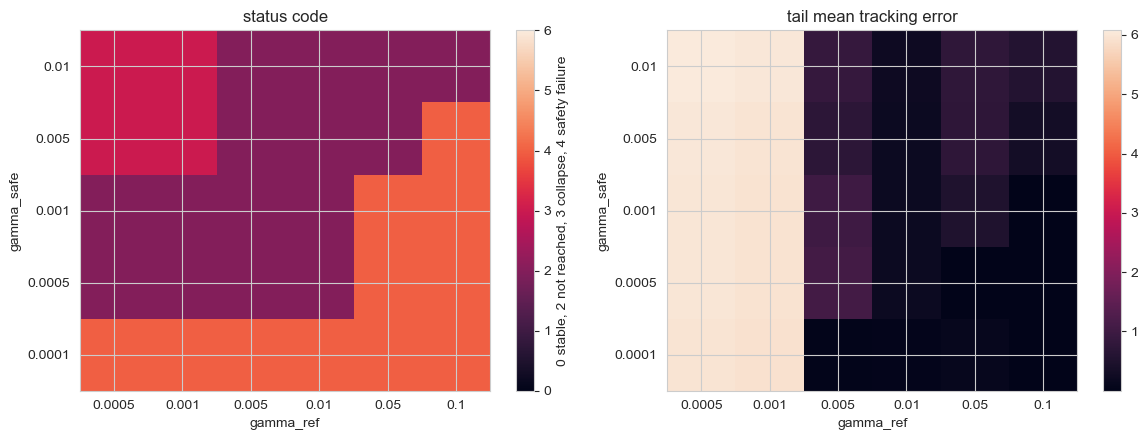

,gamma_ref,gamma_safe,status,tail_mean_tracking_error,direction_reversals,backtrack_ratio,predicted_safe_fraction,guard_cap_fraction,wall_time_s
0,0.0005,0.0100,collapse,6.076667,25,0.943664,1.000000,0.000000,0.634672
1,0.0010,0.0100,collapse,6.027681,48,0.856040,1.000000,0.000000,0.713699
2,0.0005,0.0050,collapse,6.023767,48,0.919529,1.000000,0.000000,0.685991
3,0.0005,0.0010,not_reached,5.987479,1,0.148824,1.000000,0.000000,1.125844
4,0.0005,0.0005,not_reached,5.982485,0,0.000000,1.000000,0.000000,1.551724
5,0.0010,0.0050,collapse,5.980628,95,0.746596,1.000000,0.000000,0.783753
6,0.0005,0.0001,safety_failure,5.975204,0,0.000000,0.990000,0.010000,5.836993
7,0.0010,0.0010,not_reached,5.955562,0,0.000000,1.000000,0.000000,1.480212
8,0.0010,0.0005,not_reached,5.943372,0,0.000000,1.000000,0.000000,2.339069
9,0.0010,0.0001,safety_failure,5.933101,0,0.000000,0.966667,0.033333,8.907151


In [7]:
RUN_INTERACTION_GRID = True
GAMMA_REF_GRID = [5e-4, 1e-3, 5e-3, 1e-2, 5e-2, 1e-1]
GAMMA_SAFE_GRID = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2]

grid_rows = []
if RUN_INTERACTION_GRID:
    for gamma_ref in GAMMA_REF_GRID:
        for gamma_safe in GAMMA_SAFE_GRID:
            label = f"grid_ref={gamma_ref:g}_safe={gamma_safe:g}"
            print(f"running {label}")
            row = run_case(
                label,
                safe_overrides={
                    "gamma_ref": gamma_ref,
                    "gamma_safe": gamma_safe,
                    "adaptive_gamma": False,
                },
            )
            row.update({"gamma_ref": gamma_ref, "gamma_safe": gamma_safe})
            grid_rows.append(row)

grid_df = pd.DataFrame(grid_rows)
if not grid_df.empty:
    grid_df["status"] = grid_df.apply(lambda row: _status(row), axis=1)
    status_code = {
        "stable": 0,
        "oscillatory_reached": 1,
        "not_reached": 2,
        "collapse": 3,
        "safety_failure": 4,
        "invalid": 5,
        "error": 6,
    }
    grid_df["status_code"] = grid_df["status"].map(status_code)

    status_map = grid_df.pivot(index="gamma_safe", columns="gamma_ref", values="status_code")
    error_map = grid_df.pivot(index="gamma_safe", columns="gamma_ref", values="tail_mean_tracking_error")
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    im0 = axes[0].imshow(status_map.values, origin="lower", aspect="auto", vmin=0, vmax=6)
    axes[0].set_title("status code")
    im1 = axes[1].imshow(error_map.values, origin="lower", aspect="auto")
    axes[1].set_title("tail mean tracking error")
    for ax in axes:
        ax.set_xticks(range(len(status_map.columns)), [f"{v:g}" for v in status_map.columns])
        ax.set_yticks(range(len(status_map.index)), [f"{v:g}" for v in status_map.index])
        ax.set_xlabel("gamma_ref")
        ax.set_ylabel("gamma_safe")
    fig.colorbar(im0, ax=axes[0], label="0 stable, 2 not reached, 3 collapse, 4 safety failure")
    fig.colorbar(im1, ax=axes[1])
    plt.tight_layout()
    plt.show()

    display(grid_df.sort_values("tail_mean_tracking_error", ascending=False)[
        ["gamma_ref", "gamma_safe", "status", "tail_mean_tracking_error",
         "direction_reversals", "backtrack_ratio", "predicted_safe_fraction",
         "guard_cap_fraction", "wall_time_s"]
    ].reset_index(drop=True))


## 8. Inspect the worst trajectories

Inspect the largest safety violations.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Selected: ['gamma_safe=0.1', 'gamma_ref=0.0001', 'grid_ref=0.0005_safe=0.01', 'grid_ref=0.001_safe=0.01']


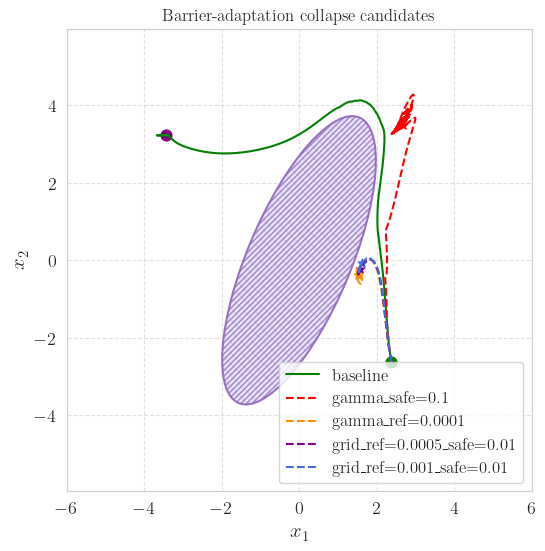

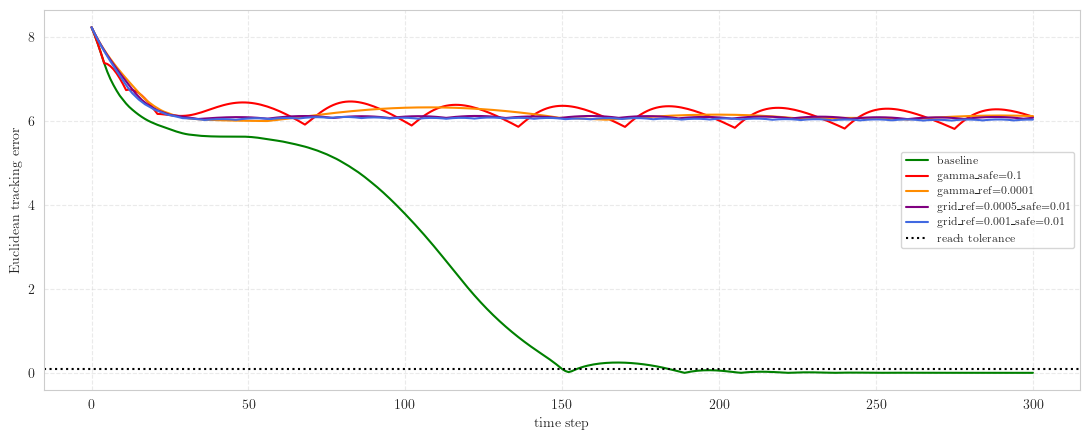

In [8]:
all_rows = factor_df.copy()
if not grid_df.empty:
    all_rows = pd.concat([all_rows, grid_df], ignore_index=True, sort=False)

available = all_rows[all_rows["label"].isin(stored_runs)]
failures = available[available["status"].isin(["collapse", "not_reached", "safety_failure"])]
if failures.empty:
    selected = available.sort_values("tail_mean_tracking_error", ascending=False).head(3)
    print("No classified collapse; plotting the three largest tail errors.")
else:
    selected = failures.sort_values("tail_mean_tracking_error", ascending=False).head(4)

selected_labels = selected["label"].tolist()
print("Selected:", selected_labels)

ellipse = cfg["ellipse"]
trajectory_items = [
    {
        "traj": stored_runs["baseline"]["result"]["x_traj"],
        "label": "baseline",
        "color": "green",
    }
]
colors = ["red", "darkorange", "purple", "royalblue"]
for color, label in zip(colors, selected_labels):
    trajectory_items.append({
        "traj": stored_runs[label]["result"]["x_traj"],
        "label": label,
        "color": color,
        "linestyle": "--",
    })

plot_trajectories_with_ellipse(
    trajectory_items,
    r=data["r"],
    p=ellipse["p"], b=ellipse["b"], c=ellipse["c"], d=ellipse["d"],
    theta=ellipse.get("theta", 0.0), xmin=-6, xmax=6,
    title="Barrier-adaptation collapse candidates",
)
plt.show()

plt.figure(figsize=(11, 4.5))
for color, label in zip(["green"] + colors, ["baseline"] + selected_labels):
    run = stored_runs[label]["result"]
    error = torch.linalg.vector_norm(run["x_traj"] - data["r"], dim=-1)[0].cpu()
    plt.plot(error, label=label, color=color)
plt.axhline(REACH_TOLERANCE, color="black", linestyle=":", label="reach tolerance")
plt.xlabel("time step")
plt.ylabel("Euclidean tracking error")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 9. Export results for joint analysis

Compare the configured methods.


In [9]:
output_dir = RESULTS / "diagnostics"
output_dir.mkdir(parents=True, exist_ok=True)
factor_path = output_dir / "barrier_collapse_factor_sweep.csv"
factor_df.to_csv(factor_path, index=False)
print("Saved:", factor_path)

if not grid_df.empty:
    grid_path = output_dir / "barrier_collapse_gamma_grid.csv"
    grid_df.to_csv(grid_path, index=False)
    print("Saved:", grid_path)

analysis_columns = [
    "label", "status", "final_tracking_error", "tail_mean_tracking_error",
    "direction_reversals", "backtrack_ratio", "predicted_safe_fraction",
    "guard_cap_fraction", "total_safety_iters", "smooth_rms_du", "wall_time_s",
]
display(all_rows.sort_values(
    ["status", "tail_mean_tracking_error"], ascending=[True, False]
)[analysis_columns].reset_index(drop=True))


Saved: /Users/alireza/Documents/PythonProject/gptSparseDPC/SparseDPC/6_Relative_Degree_One/DoubleIntegrator/results/diagnostics/barrier_collapse_factor_sweep.csv
Saved: /Users/alireza/Documents/PythonProject/gptSparseDPC/SparseDPC/6_Relative_Degree_One/DoubleIntegrator/results/diagnostics/barrier_collapse_gamma_grid.csv


,label,status,final_tracking_error,tail_mean_tracking_error,direction_reversals,backtrack_ratio,predicted_safe_fraction,guard_cap_fraction,total_safety_iters,smooth_rms_du,wall_time_s
0,gamma_safe=0.1,collapse,6.101387,6.124781,13,1.405186,1.0,0.0,10,0.071716,0.634999
1,gamma_ref=0.0001,collapse,6.116920,6.119328,7,0.877090,1.0,0.0,13,0.006982,0.717623
2,grid_ref=0.0005_safe=0.01,collapse,6.076606,6.076667,25,0.943664,1.0,0.0,20,0.015755,0.634672
3,grid_ref=0.001_safe=0.01,collapse,6.033389,6.027681,48,0.856040,1.0,0.0,35,0.020106,0.713699
4,gamma_ref=0.0005,collapse,6.030238,6.023767,48,0.919529,1.0,0.0,39,0.011074,0.705961
...,...,...,...,...,...,...,...,...,...,...,...
74,obstacle_band=1,stable,0.000033,0.000147,4,0.071025,1.0,0.0,44,0.015660,0.686778
75,obstacle_band=0.5,stable,0.000077,0.000123,4,0.069174,1.0,0.0,39,0.015336,0.674311
76,safety_grad_max_norm=20,stable,0.000009,0.000029,6,0.046590,1.0,0.0,12,0.033564,0.625467
77,safety_grad_max_norm=5,stable,0.000009,0.000026,5,0.036867,1.0,0.0,12,0.028172,0.620282


## How to interpret the results

Summarize the comparison.
